<a href="https://colab.research.google.com/github/JungYeoni/study_torch/blob/main/%EB%8B%A4%EC%A4%91_%EC%84%A0%ED%98%95_%ED%9A%8C%EA%B7%80(Multivariable_Linear_regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 다중 선형 회귀(Multivariable Linear regression)

다수의 $x$로부터 $y$를 예측한다.
- 3개의 퀴즈 점수로부터 최종 점수 예측하는 모델 만들기

## 데이터에 대한 이해

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
# 시드 고정
torch.manual_seed(1)

## 파이토치로 구현하기

In [3]:
# 훈련 데이터 선언
x1_train = torch.FloatTensor([[73], [93], [89], [96], [73]])
x2_train = torch.FloatTensor([[80], [88], [91], [98], [66]])
x3_train = torch.FloatTensor([[75], [93], [90], [100], [70]])
y_train = torch.FloatTensor([[152], [185], [180], [196], [142]])

In [5]:
# 가중치와 편향 초기화
w1 = torch.zeros(1, requires_grad=True)
w2 = torch.zeros(1, requires_grad=True)
w3 = torch.zeros(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [6]:
# optimizer 설정
optimizer = optim.SGD([w1, w2, w3, b], lr=1e-5)

nb_epochs = 1000

for epoch in range(nb_epochs + 1):
  # H(x) 계산
  hypothesis = x1_train * w1 + x2_train * w2 + x3_train * w3 + b

  # cost 계산
  cost = torch.mean((hypothesis - y_train) ** 2)

  # cost로 H(x) 계산
  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  # 100마다 로그 출력
  if epoch % 100 == 0:
    print('Epoch {:4d}/{} w1: {:.3f} w2: {:.3f} w3: {:.3f} b: {:.3f} Cost: {:.6f}'.format(
        epoch, nb_epochs, w1.item(), w2.item(), w3.item(), b.item(), b.item(), cost.item()
    ) )

Epoch    0/1000 w1: 0.294 w2: 0.294 w3: 0.297 b: 0.003 Cost: 0.003420
Epoch  100/1000 w1: 0.674 w2: 0.661 w3: 0.676 b: 0.008 Cost: 0.007920
Epoch  200/1000 w1: 0.679 w2: 0.655 w3: 0.677 b: 0.008 Cost: 0.008070
Epoch  300/1000 w1: 0.684 w2: 0.649 w3: 0.677 b: 0.008 Cost: 0.008219
Epoch  400/1000 w1: 0.689 w2: 0.643 w3: 0.678 b: 0.008 Cost: 0.008367
Epoch  500/1000 w1: 0.694 w2: 0.638 w3: 0.678 b: 0.009 Cost: 0.008514
Epoch  600/1000 w1: 0.699 w2: 0.633 w3: 0.679 b: 0.009 Cost: 0.008659
Epoch  700/1000 w1: 0.704 w2: 0.627 w3: 0.679 b: 0.009 Cost: 0.008804
Epoch  800/1000 w1: 0.709 w2: 0.622 w3: 0.679 b: 0.009 Cost: 0.008948
Epoch  900/1000 w1: 0.713 w2: 0.617 w3: 0.680 b: 0.009 Cost: 0.009090
Epoch 1000/1000 w1: 0.718 w2: 0.613 w3: 0.680 b: 0.009 Cost: 0.009232


## 벡터와 행렬 연산으로 바꾸기

- 위에서는 x1, x2 이런식으로 일일히 선언
- 이를 해결하기 위해 행렬 곱셈 연산 (또는 내적)을 사용함.

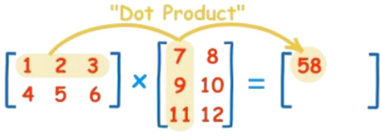

In [7]:
# 훈련 데이터를 행렬로 선언
x_train = torch.FloatTensor([
    [73, 80, 75],
    [89, 88, 93],
    [89, 91, 80],
    [96, 98, 100],
    [73, 66, 70]
])

y_train = torch.FloatTensor([
    [152],
    [185],
    [180],
    [196],
    [142]
])

In [9]:
# 크기 출력
print(x_train.shape)
print(y_train.shape)

torch.Size([5, 3])
torch.Size([5, 1])


In [11]:
# 가중치와 편향 선언
W = torch.zeros((3, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [12]:
# 행렬곱으로 가설 선언
hypothesis = x_train.matmul(W) + b

- 이 경우에는 사용자가 독립변수를 수정하더라도 가설 선언 코드를 수정할 필요가 없다

In [13]:
# 이를 반영한 전체 코드

# 훈련 데이터를 행렬로 선언
x_train = torch.FloatTensor([
    [73, 80, 75],
    [89, 88, 93],
    [89, 91, 80],
    [96, 98, 100],
    [73, 66, 70]
])

y_train = torch.FloatTensor([
    [152],
    [185],
    [180],
    [196],
    [142]
])

# 모델 초기화
W = torch.zeros((3, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

# optimizer 설정
optimizer = optim.SGD([W, b], lr=1e-5)

nb_epochs = 20

for epoch in range(nb_epochs + 1):
  # H(x) 계산
  hypothesis = x1_train * w1 + x2_train * w2 + x3_train * w3 + b

  # cost 계산
  cost = torch.mean((hypothesis - y_train) ** 2)

  # cost로 H(x) 계산
  optimizer.zero_grad()
  cost.backward()
  optimizer.step()

  # 100마다 로그 출력
  if epoch % 100 == 0:
    print('Epoch {:4d}/{} w1: {:.3f} w2: {:.3f} w3: {:.3f} b: {:.3f} Cost: {:.6f}'.format(
        epoch, nb_epochs, w1.item(), w2.item(), w3.item(), b.item(), b.item(), cost.item()
    ) )

Epoch    0/20 w1: 0.718 w2: 0.613 w3: 0.680 b: 0.000 Cost: 0.000002


In [17]:
# 학습이 끝난 모델에 임의의 입력값 넣어 예측
with torch.no_grad():
  new_input = torch.FloatTensor([[75, 85, 72]]) # 예측하고 싶은 임의의 입력
  prediction = new_input.matmul(W) + b # 학습한 가중치와 편향을 입력값으로 넣어줌
  print('Predicted value for input {}:{}'.format(new_input.squeeze().tolist(), prediction.item()) )

Predicted value for input [75.0, 85.0, 72.0]:3.349024336785078e-05


- `with torch.no_grad`: 이 안에서 수행되는 모든 연산에 대해 역전파(기울기 계산)를 비활성화

예측을 할 때는 가중치 업데이트를 할 필요가 없기 때문에, 메모리와 계산 자원을 절약하기 위해 `torch.no_grad()`를 사용하는 것이 좋음

- `prediction.item()`: 텐서로 반환된 예측 값을 파이썬 숫자 자료형으로 변환해 출력